In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- 1. DATA PREPARATION ---
df = pd.read_csv('merged.csv')
df['Stock_Timestamp'] = pd.to_datetime(df['Stock_Timestamp'], utc=True)
df = df.sort_values('Stock_Timestamp').reset_index(drop=True)

# --- 2. BASELINE FEATURE SELECTION (OHLCV ONLY) ---
feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume']

# Target: 1 if the NEXT minute's candle is green (Next Close > Next Open)
# This perfectly aligns with our slippage execution logic
df['Target'] = (df['Close'].shift(-1) > df['Open'].shift(-1)).astype(int)
model_df = df[feature_cols + ['Target']].dropna()

# --- 3. CHRONOLOGICAL SPLIT (70/20/10) ---
n = len(model_df)
train_idx = int(n * 0.70)
val_idx = int(n * 0.90) 

X = model_df[feature_cols].values
y = model_df['Target'].values

X_train, y_train = X[:train_idx], y[:train_idx]
X_val, y_val = X[train_idx:val_idx], y[train_idx:val_idx]
X_test, y_test = X[val_idx:], y[val_idx:]

# --- 4. SCALING (FIT ONLY ON TRAIN) ---
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


In [4]:
# --- 5. TABNET MODEL DEFINITION ---
tabnet_model = TabNetClassifier(
    n_d=16, n_a=16, n_steps=3,
    gamma=1.3, n_independent=2, n_shared=2,
    lambda_sparse=1e-3, optimizer_params=dict(lr=2e-2),
    mask_type='entmax' 
)

# --- 6. TRAINING ---
tabnet_model.fit(
    X_train=X_train, y_train=y_train,
    eval_set=[(X_val, y_val)],
    eval_name=['valid'],
    eval_metric=['accuracy'],
    max_epochs=50, 
    patience=10,
    batch_size=1024, 
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False
)

C:\Users\abdur\AppData\Roaming\Python\Python313\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.7118  | valid_accuracy: 0.49536 |  0:00:02s
epoch 1  | loss: 0.69692 | valid_accuracy: 0.50681 |  0:00:04s
epoch 2  | loss: 0.69558 | valid_accuracy: 0.50553 |  0:00:06s
epoch 3  | loss: 0.69424 | valid_accuracy: 0.50758 |  0:00:09s
epoch 4  | loss: 0.69424 | valid_accuracy: 0.49264 |  0:00:11s
epoch 5  | loss: 0.69394 | valid_accuracy: 0.50769 |  0:00:13s
epoch 6  | loss: 0.69378 | valid_accuracy: 0.50619 |  0:00:15s
epoch 7  | loss: 0.69374 | valid_accuracy: 0.49753 |  0:00:17s
epoch 8  | loss: 0.69381 | valid_accuracy: 0.50664 |  0:00:19s
epoch 9  | loss: 0.69353 | valid_accuracy: 0.50708 |  0:00:21s
epoch 10 | loss: 0.69351 | valid_accuracy: 0.50786 |  0:00:23s
epoch 11 | loss: 0.6934  | valid_accuracy: 0.50714 |  0:00:26s
epoch 12 | loss: 0.69338 | valid_accuracy: 0.50808 |  0:00:28s
epoch 13 | loss: 0.69337 | valid_accuracy: 0.50647 |  0:00:30s
epoch 14 | loss: 0.69337 | valid_accuracy: 0.50764 |  0:00:32s
epoch 15 | loss: 0.69335 | valid_accuracy: 0.50814 |  0

C:\Users\abdur\AppData\Roaming\Python\Python313\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [5]:
# --- 7. STATISTICAL EVALUATION ---
y_pred_probs = tabnet_model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_probs > 0.50).astype(int)

print("\n" + "="*50)
print("       TABNET BASELINE STATISTICAL PERFORMANCE")
print("="*50)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Down/Flat (0)', 'Up (1)']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


       TABNET BASELINE STATISTICAL PERFORMANCE
Test Accuracy: 49.95%

Classification Report:
               precision    recall  f1-score   support

Down/Flat (0)       0.50      0.47      0.49      4523
       Up (1)       0.50      0.53      0.51      4476

     accuracy                           0.50      8999
    macro avg       0.50      0.50      0.50      8999
 weighted avg       0.50      0.50      0.50      8999


Confusion Matrix:
[[2143 2380]
 [2124 2352]]



       TABNET BASELINE FINANCIAL PERFORMANCE
Initial Capital:         $10,000.00
Total Net Profit:        $-2,249.55
Final Account Balance:   $7,750.45
Return on Investment:    -22.50%


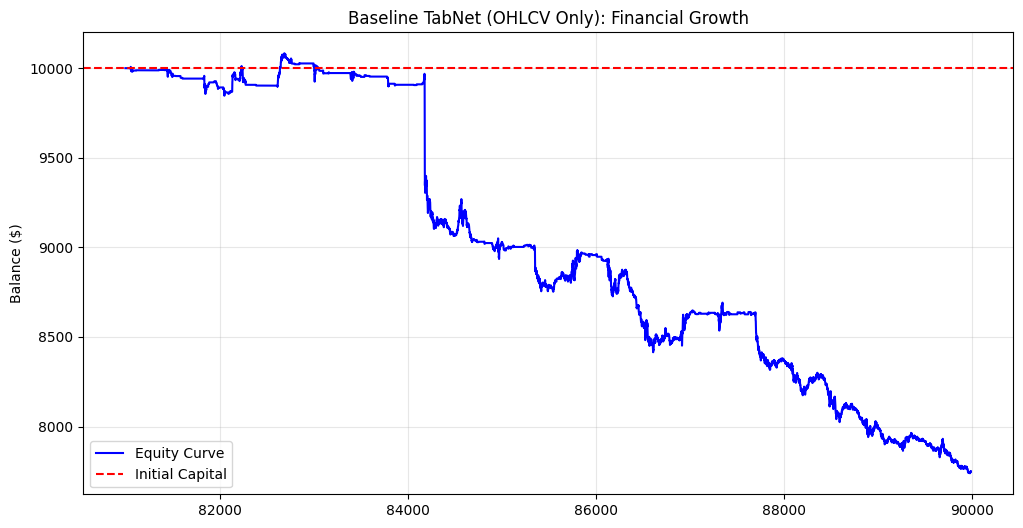

In [7]:
# --- 8. FINANCIAL BACKTESTING ---
# Align prediction results with original price data
df_results = model_df.iloc[val_idx:].copy()
df_results['Prob_Up'] = y_pred_probs

# Signal at T (Threshold 0.55 for higher confidence)
THRESHOLD = 0.50
df_results['Signal'] = (df_results['Prob_Up'] > THRESHOLD).astype(int)

# SLIPPAGE MODELING:
# Decision at Close of T -> Entry at Open of T+1 -> Exit at Close of T+1
df_results['Entry_Price'] = df_results['Open'].shift(-1)
df_results['Exit_Price'] = df_results['Close'].shift(-1)
df_results = df_results.dropna(subset=['Entry_Price', 'Exit_Price'])

# --- 9. CAPITAL TRACKING ---
INITIAL_CAPITAL = 10000.0
FEE_PER_SHARE = 0.009 
current_capital = INITIAL_CAPITAL
capital_history = []

for idx, row in df_results.iterrows():
    if row['Signal'] == 1:
        # Calculate shares (Full capital reinvestment)
        shares = np.floor(current_capital / row['Entry_Price'])
        
        # Calculate Gross profit using the slippage execution prices
        gross_pnl = (row['Exit_Price'] - row['Entry_Price']) * shares
        
        # Calculate Round-trip transaction fees
        fees = shares * FEE_PER_SHARE
        
        # Update capital with Net PnL
        current_capital += (gross_pnl - fees)
        
    capital_history.append(current_capital)

df_results['Account_Balance'] = capital_history
profit = current_capital - INITIAL_CAPITAL

print("\n" + "="*50)
print("       TABNET BASELINE FINANCIAL PERFORMANCE")
print("="*50)
print(f"Initial Capital:         ${INITIAL_CAPITAL:,.2f}")
print(f"Total Net Profit:        ${profit:,.2f}")
print(f"Final Account Balance:   ${current_capital:,.2f}")
print(f"Return on Investment:    {(profit/INITIAL_CAPITAL)*100:.2f}%")
print("="*50)

# --- 10. VISUALIZATION ---
plt.figure(figsize=(12, 6))
plt.plot(df_results.index, df_results['Account_Balance'], color='blue', label='Equity Curve')
plt.axhline(INITIAL_CAPITAL, color='red', linestyle='--', label='Initial Capital')
plt.title(f'Baseline TabNet (OHLCV Only): Financial Growth')
plt.ylabel('Balance ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()